In [1]:
nest = True
target_y = 1273

In [2]:
from dask.distributed import Client
client = Client(n_workers=12, threads_per_worker=1, memory_limit='7GB')
# print the dashboard link
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 12
Total threads: 12,Total memory: 78.23 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34667,Workers: 12
Dashboard: http://127.0.0.1:8787/status,Total threads: 12
Started: Just now,Total memory: 78.23 GiB
Comm: tcp://127.0.0.1:34143,Total threads: 1
Dashboard: http://127.0.0.1:40765/status,Memory: 6.52 GiB
Nanny: tcp://127.0.0.1:36339,


In [2]:
import xarray as xr
import numpy as np
from pathlib import Path
import gsw
from xarray import open_mfdataset, open_dataset
from matplotlib import pyplot as plt



# Utilities 
def find_grid_files(grid_type, years, nest, model, delta_t, folder = 'output'): 
    experiment_path = Path('/gxfs_work/geomar/smomw355/model_data/ocean-only/')
    nest_part = '1_' if nest else '' 

    if len(grid_type) < 2:
        grid_type = f'grid_{grid_type}'

    grid_files = (experiment_path / model / 'nemo' / folder).glob(f'{nest_part}{model}_{delta_t}_*_*_{grid_type}.nc')
    grid_files = list(grid_files)
    
    result_files = []
    for file in grid_files:
        start_year = int(str(file).split('/')[-1].split('_')[- (3 + grid_type.count('_'))][:4])
        
        if (years[0] is None or start_year >= years[0]) and \
           (years[1] is None or start_year < years[1]):
            result_files.append(file)
    
    return sorted(result_files)

def load_dataset_from_grid_type(grid_type, years, nest, model, delta_t, chunks = {"time_counter" : 2,"y": 2, "x": None}, **kwargs):
    files_list = find_grid_files(grid_type, years, nest, model, delta_t, **kwargs)
    grid = open_mfdataset(
        files_list, # type: ignore
        chunks= chunks,
        combine='by_coords'
    )
    return grid

def load_masks(nest, model):

    if str.startswith(model, 'VIKING20X.L46-KFS003'):
        # All the mask for the long runs VIKING20X.L46-KFS003-2nd, ... are placed in the original experiment
        model = 'VIKING20X.L46-KFS003' 
    
    nest_part = '1_' if nest else ''
    
    mask_mesh = open_dataset(
        f'/gxfs_work/geomar/smomw355/model_data/ocean-only/{model}/nemo/suppl/{nest_part}mesh_mask.nc',
        decode_cf=False,
        chunks={'y': 100, 'x':100, 'z': -1},
    )

    if model == 'VIKING20X.L46-KFS003' and not nest:
        nest_part = 'ori_'

    mask_glo = open_dataset(
        f'/gxfs_work/geomar/smomw355/model_data/ocean-only/{model}/nemo/suppl/{nest_part}new_maskglo.nc',
        decode_cf=False,
        chunks={'Y':100, 'X':100, 'z': -1}
    )

    mask_mesh = mask_mesh.squeeze()
    mask_glo = mask_glo.rename({'X':'x', 'Y':'y'}).squeeze() # Rename coordinates to have the same name as the data file
    
    return mask_mesh, mask_glo



## Xarray Implementation

In [15]:

ds_T = load_dataset_from_grid_type('T', (1970, 1971), nest, 'VIKING20X.L46-KFS003', '1m', chunks={'x': 100, 'y': 100, 'time_counter': 1, 'deptht': -1})

ds_V = load_dataset_from_grid_type('V', (1970, 1971), nest, 'VIKING20X.L46-KFS003', '1m', chunks={'x': 100, 'y': 100, 'time_counter': 1, 'deptht': -1})

# ds_T = ds_T.isel(time_counter=0, drop=True)
ds_T = ds_T.rename({"deptht": "z"})
ds_T = ds_T.assign_coords(x=np.arange(ds_T.dims["x"]), y=np.arange(ds_T.dims["y"]))

ds_V = ds_V.rename({"depthv": "z"})
ds_V = ds_V.assign_coords(x=np.arange(ds_V.dims["x"]), y=np.arange(ds_V.dims["y"]))
ds_T

<xarray.Dataset>
Dimensions:               (y: 2499, x: 2404, z: 46, axis_nbounds: 2,
                           time_counter: 12)
Coordinates:
    nav_lat               (y, x) float32 dask.array<chunksize=(100, 100), meta=np.ndarray>
    nav_lon               (y, x) float32 dask.array<chunksize=(100, 100), meta=np.ndarray>
  * z                     (z) float32 3.047 9.454 16.36 ... 5.625e+03 5.875e+03
    time_centered         (time_counter) datetime64[ns] dask.array<chunksize=(1,), meta=np.ndarray>
  * time_counter          (time_counter) datetime64[ns] 1970-01-16T12:00:00 ....
  * x                     (x) int64 0 1 2 3 4 5 ... 2399 2400 2401 2402 2403
  * y                     (y) int64 0 1 2 3 4 5 ... 2494 2495 2496 2497 2498
Dimensions without coordinates: axis_nbounds
Data variables: (12/18)
    deptht_bounds         (z, axis_nbounds) float32 dask.array<chunksize=(46, 2), meta=np.ndarray>
    time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] dask.array<chunksize=(1, 2), meta=np.ndarray>
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] dask.array<chunksize=(1, 2), meta=np.ndarray>
    votemper              (time_counter, z, y, x) float32 dask.array<chunksize=(1, 46, 100, 100), meta=np.ndarray>
    vosaline              (time_counter, z, y, x) float32 dask.array<chunksize=(1, 46, 100, 100), meta=np.ndarray>
    sosstsst              (time_counter, y, x) float32 dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
    ...                    ...
    sohefldo              (time_counter, y, x) float32 dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
    somixhgt              (time_counter, y, x) float32 dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
    sowindsp              (time_counter, y, x) float32 dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
    sohefldp              (time_counter, y, x) float32 dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
    sowafldp              (time_counter, y, x) float32 dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
    sobowlin              (time_counter, y, x) float32 dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
Attributes:
    name:         /p/scratch/viking/schwarzkopf1/VIKING20X.L46/VIKING20X.L46-...
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2020-Dec-19 08:20:04 GMT
    uuid:         84af2a2f-fbb6-49dc-bcad-3da2e42d5791
    history:      Tue Dec 22 10:56:31 2020: ncrcat 1_VIKING20X.L46-KFS003_1m_...
    NCO:          netCDF Operators version 4.9.6 (Homepage = http://nco.sf.ne...

In [5]:
ds_m, ds_mask = load_masks(nest, 'VIKING20X.L46-KFS003')
ds_m = ds_m.assign_coords(x=np.arange(ds_m.dims["x"]), y=np.arange(ds_m.dims["y"]))
# ds_mask = ds_mask.rename({"X": "x", "Y": "y"})
ds_mask = ds_mask.assign_coords(x=np.arange(ds_mask.dims["x"]), y=np.arange(ds_mask.dims["y"]))

In [6]:
pot_temp = ds_T.votemper
salinity = ds_T.vosaline

pot_temp = pot_temp.where((ds_m.tmask == 1) & (ds_m.tmaskutil == 1))
salinity = salinity.where((ds_m.tmask == 1) & (ds_m.tmaskutil == 1))

ct = gsw.CT_from_pt(salinity, pot_temp)
rho = gsw.rho(salinity, ct, ds_T.z).rename("dens")

In [41]:
drho_dx = (rho.diff("x") / ds_m.e1t).rename("drho_dx")

f = 2 * 7.2921e-5 * np.sin(np.deg2rad(ds_m.gphit))
f = f.where(abs(ds_m.gphit) > 5)
g = 9.81

dv_dz = - g / f / rho * drho_dx

v = (dv_dz * ds_m.e3t_0).isel(z=slice(None, None, -1)).cumsum("z").isel(z=slice(None, None, -1))
v = v.where(~dv_dz.isnull())
dvbt = ((ds_m.e3v_0 * ds_m.vmask) * ds_V.vomecrty).sum('z')
depth = (ds_m.e3v_0 * ds_m.vmask).sum('z')
dvbt = dvbt /depth

dvbt = dvbt.where(ds_mask.tmaskatl == 1)

amoc_bt = dvbt * (ds_m.e1v * ds_m.e3v_0 * ds_m.vmask)
amoc_bt = (-amoc_bt).sum('x')


amoc_sh = (v.where(ds_mask.tmaskatl == 1) * ds_m.e1t * ds_m.e3t_0).sum("x")

amoc = (amoc_sh - amoc_bt).isel(z=slice(None, None, -1)).cumsum("z").isel(z=slice(None, None, -1))
amoc

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=

<xarray.DataArray (y: 2499, time_counter: 12, z: 46)>
dask.array<getitem, shape=(2499, 12, 46), dtype=float64, chunksize=(100, 1, 46), chunktype=numpy.ndarray>
Coordinates:
  * y              (y) int64 0 1 2 3 4 5 6 ... 2493 2494 2495 2496 2497 2498
  * z              (z) float32 3.047 9.454 16.36 ... 5.625e+03 5.875e+03
  * time_counter   (time_counter) datetime64[ns] 1970-01-16T12:00:00 ... 1970...
    time_centered  (time_counter) datetime64[ns] 1970-01-16T12:00:00 ... 1970...
    T              float64 1.0

In [42]:
geo_moc_calc = (amoc / 1e6).rename("Geostrophic AMOC [Sv]").isel(y = target_y, z = 24).compute()

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/dask/core.py:121: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/dask/core.py:121: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/dask/core.py:121: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/dask/core.py:121: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/dask/core.py:121: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a

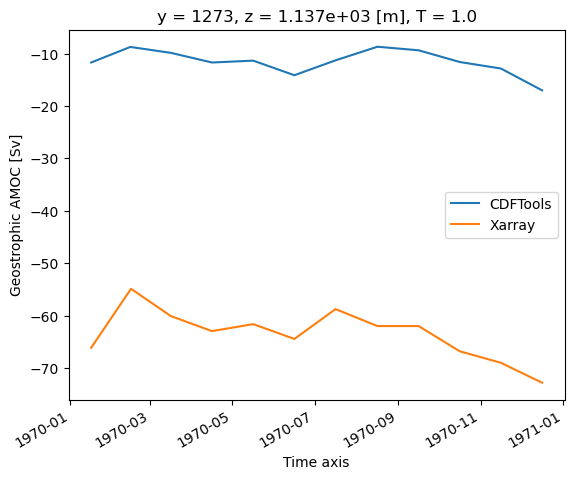

In [48]:
geo_moc = load_dataset_from_grid_type('moc', (1970, 1971), nest, 'VIKING20X.L46-KFS003', '1m', chunks={'y': 100, 'time_counter': 1}, folder = 'derived')

geo_moc.zomsfatl_sh.isel(y = target_y, depthw = 24).plot(label = 'CDFTools')
# geo_moc.zomsfatl_ageo.isel(y = target_y, depthw = 24).plot()
geo_moc_calc.plot(label = "Xarray")
plt.legend()



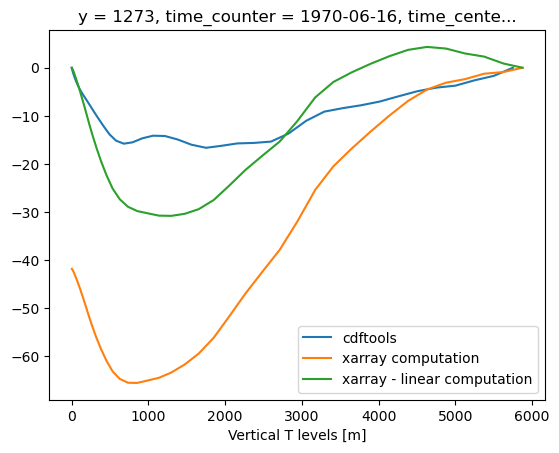

In [50]:
cdftools_profile = geo_moc.zomsfatl_sh.isel(time_counter = 5, y = 1273)
cdftools_profile = cdftools_profile.assign_coords(depthw=-cdftools_profile.depthw)
cdftools_profile.plot(label = 'cdftools')
moc_calc = (amoc / 1e6).rename("Geostrophic AMOC [Sv]").isel(y = 1273, time_counter = 5)

moc_calc.plot(label = 'xarray computation')
linear = moc_calc.isel(z = 0) + (moc_calc.isel(z = -1) - moc_calc.isel(z = 0)) / moc_calc.z.isel(z = -1) * moc_calc.z 

(moc_calc - linear).plot(label = 'xarray - linear computation')

plt.legend()

# Calculate like CDF Tools from Density

In [3]:
import xarray as xr
import numpy as np

rho = xr.open_dataset('/gxfs_work/geomar/smomw507/geomar/amoc-reconstruction/data/cdfgeostrophic/1_VIKING20X.L46-KFS003_1m_19700101_19701231_dens.nc', chunks={'y': 100, 'x':100, 'time_counter': 1})
rho = rho.rename({"deptht": "z"})
rho = rho.assign_coords(x=np.arange(rho.dims["x"]), y=np.arange(rho.dims["y"]))

rho = rho.vosigmainsitu


/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [11]:
rho = rho.isel(y = slice(1265,1280))

In [4]:
ds_m, ds_mask = load_masks(nest, 'VIKING20X.L46-KFS003')
ds_m = ds_m.assign_coords(x=np.arange(ds_m.dims["x"]), y=np.arange(ds_m.dims["y"]))
ds_mask = ds_mask.assign_coords(x=np.arange(ds_mask.dims["x"]), y=np.arange(ds_mask.dims["y"]))

## Numpy Implementation

In [5]:
dens_all_t = rho.transpose('time_counter', 'x', 'y', 'z').values
tmask = ds_m.tmask.transpose('x', 'y', 'z').values
umask = ds_m.umask.transpose('x', 'y', 'z').values
vmask = ds_m.vmask.transpose('x', 'y', 'z').values
e1u = ds_m.e1u.transpose('x', 'y').values
e1v = ds_m.e1v.transpose('x', 'y').values
e3v = ds_m.e3v_0.transpose('x', 'y', 'z').values * vmask
gphiv = ds_m.gphiv.transpose('x', 'y').values
tmaskatl = ds_mask.tmaskatl.transpose('x', 'y').values

## Variant with for loops 

In [6]:
rau0 = 1025.0
grav = 9.81
rpi = np.pi

zcoef = 2 * 2 * rpi / (24.0 * 3600.0) * np.sin(np.deg2rad(gphiv))
zcoef = np.where(np.abs(gphiv) > 5, - grav / rau0 / zcoef, 0)

In [47]:
time_i = 0


npiglo = dens_all_t.shape[1]
npjglo = dens_all_t.shape[2]
npk = dens_all_t.shape[3]

dvgeo = np.zeros(shape = (npiglo, npjglo, 2))
dvbt = np.zeros_like(e1u)
hdep = np.zeros_like(e1u)

zv = np.zeros(shape = (npiglo, npjglo))
# zv = vomecrty[time_i, :, :, npk-2]

dmoc_sh = np.zeros(shape = (npjglo, npk))


iup = 0
ido = 1


from time import time 

for jk in range(npk - 2, -1, -1):

    start_time = time()

    iumask = umask[:, :, jk]
    itmask = tmask[:, :, jk]

    zsig0 = np.nan_to_num(dens_all_t[time_i, :, :, jk]) * itmask

    # for jj in range(1, npjglo - 1):
    for jj in range(1265,1280):
        for ji in range(1, npiglo - 1):

            zmsv = 1./ max(1, iumask[ji-1,jj+1]+iumask[ji,jj+1]+iumask[ji-1,jj]+iumask[ji,jj])

            dgeo = ( ( zsig0[ji,  jj+1] - zsig0[ji-1,jj+1] ) * iumask[ji-1, jj+1] / e1u[ji-1, jj+1]
                    +( zsig0[ji+1,jj+1] - zsig0[ji  ,jj+1] ) * iumask[ji,   jj+1] / e1u[ji,   jj+1]
                    +( zsig0[ji,  jj  ] - zsig0[ji-1,jj  ] ) * iumask[ji-1, jj  ] / e1u[ji-1, jj  ]
                    +( zsig0[ji+1,jj  ] - zsig0[ji,  jj  ] ) * iumask[ji,   jj  ] / e1u[ji,   jj  ]  )
            
            dvgeo[ji,jj,iup] = dvgeo[ji,jj,ido] + zcoef[ji,jj] * dgeo * zmsv * tmaskatl[ji,jj] * e3v_masked[ji,jj,jk]

            zv[ji,jj] = .5 * (dvgeo[ji,jj,iup] + dvgeo[ji,jj,ido])
        
    dvbt = dvbt + zv * e3v_masked[:,:,jk] 
    hdep = hdep + e3v_masked[:,:,jk]

    for ji in range(npiglo):
        # for jj in range(npjglo):
        for jj in range(1265,1280):
            dmoc_sh[jj, jk] = dmoc_sh[jj, jk] - e1v[ji, jj] * e3v_masked[ji, jj, jk] * tmaskatl[ji, jj] * zv[ji, jj]

    itmp = iup
    iup = ido
    ido = itmp

    print('Done k: ', jk, f'Time: {time() - start_time:.2f}s', )

dvbt = np.where(hdep > 0, dvbt / hdep, 0)

dmoc_btw = np.zeros_like(dmoc_sh)

for jk in range(npk - 1):
    for ji in range(npiglo):
        # for jj in range(npjglo):
        for jj in range(1265,1280):
            dmoc_btw[jj, jk] = dmoc_btw[jj, jk] - e1v[ji, jj] * e3v_masked[ji, jj, jk] * tmaskatl[ji, jj] * dvbt[ji, jj]


dmoc_sh = dmoc_sh - dmoc_btw

for jk in range(npk - 2, -1, -1):
    dmoc_sh[:, jk] = dmoc_sh[:, jk + 1] + dmoc_sh[:, jk] / 1e6




Done k:  44 Time: 0.67s
Done k:  43 Time: 0.64s
Done k:  42 Time: 0.66s
Done k:  41 Time: 0.65s
Done k:  40 Time: 0.66s
Done k:  39 Time: 0.65s
Done k:  38 Time: 0.66s
Done k:  37 Time: 0.65s
Done k:  36 Time: 0.66s
Done k:  35 Time: 0.65s
Done k:  34 Time: 0.67s
Done k:  33 Time: 0.65s
Done k:  32 Time: 0.66s
Done k:  31 Time: 0.65s
Done k:  30 Time: 0.67s
Done k:  29 Time: 0.65s
Done k:  28 Time: 0.66s
Done k:  27 Time: 0.65s
Done k:  26 Time: 0.67s
Done k:  25 Time: 0.65s
Done k:  24 Time: 0.67s
Done k:  23 Time: 0.65s
Done k:  22 Time: 0.67s
Done k:  21 Time: 0.66s
Done k:  20 Time: 0.67s
Done k:  19 Time: 0.65s
Done k:  18 Time: 0.67s
Done k:  17 Time: 0.66s
Done k:  16 Time: 0.67s
Done k:  15 Time: 0.65s
Done k:  14 Time: 0.67s
Done k:  13 Time: 0.65s
Done k:  12 Time: 0.67s
Done k:  11 Time: 0.65s
Done k:  10 Time: 0.67s
Done k:  9 Time: 0.66s
Done k:  8 Time: 0.66s
Done k:  7 Time: 0.65s
Done k:  6 Time: 0.66s
Done k:  5 Time: 0.66s
Done k:  4 Time: 0.68s
Done k:  3 Time: 0.65s

/scratch/SlurmTMP/smomw507.11112384/ipykernel_4072623/4277879186.py:62: RuntimeWarning: invalid value encountered in divide
  dvbt = np.where(hdep > 0, dvbt / hdep, 0)


In [48]:
dmoc_sh[1273, 24]

-11.67308754494644

## Variant 1

In [ ]:
rpi = np.arccos(-1)

zcoef = 2*2*rpi/( 24.0 * 3600. )* np.sin ( rpi * gphiv /180.0)
zcoef = np.where(np.abs(gphiv) > 5, zcoef, np.nan)

zcoef = np.where(zcoef != 0, -9.81 / 1025.0 / zcoef, 0.0)

In [ ]:
amoc = np.empty(shape = (dens_all_t.shape[0], dens_all_t.shape[2], dens_all_t.shape[3]))
for ti, dens in enumerate(dens_all_t): 

    diff = np.diff(dens, axis = 0)

    # multiply elementwise with the u mask and divide by the width of the u box
    diff = (np.nan_to_num(diff) * umask[:-1, :, :]) / e1u[:-1, :, np.newaxis]

    drho = np.zeros_like(dens)
    drho[1:-1, :-1] = diff[:-1, :-1] + diff[1:, :-1] + diff[:-1, 1:] + diff[1:, 1:] 


    zmsv = np.ones_like(dens)
    zmsv[1:, :-1] =umask[1:, :-1] + umask[:-1, :-1] + umask[1:, 1:] + umask[:-1, 1:]
    zmsv = np.where(zmsv > 0, 1 / zmsv, 1)




    dvgeo = drho * zcoef[:,:,np.newaxis] * zmsv * e3v * tmaskatl[:, :, np.newaxis]

    dvgeo = np.where(vmask == 1, dvgeo, np.nan)
    dvgeo = np.nancumsum(dvgeo[..., ::-1], axis = -1)[..., ::-1]

    # move to v level 
    zv = np.zeros_like(dvgeo)
    for zk in range(dvgeo.shape[2] -1, -1, -1):
        if zk == dvgeo.shape[2] -1:
            zv[:,:,zk] = .5 * dvgeo[:,:,zk]
        else:
            zv[:,:,zk] = .5 * (dvgeo[:,:,zk] + dvgeo[:,:,zk + 1])


    zv = np.where(vmask == 1, zv, np.nan)

    dvbt = np.nansum(e3v * zv, axis = -1)
    hdep = np.nansum(e3v, axis = -1)

    dmoc_sh = np.nansum(-e1v[:, :, np.newaxis] * e3v * zv * tmaskatl[:, :, np.newaxis], axis = 0)

    dvbt = np.where(hdep == 0, 0, dvbt / hdep)
    dvbt = np.where(tmaskatl == 1, dvbt, np.nan)

    dmoc_btw = np.nansum(-dvbt[:, :, np.newaxis] * e1v[:, :, np.newaxis] * e3v, axis = 0)

    dmoc_sh = dmoc_sh - dmoc_btw
    dmoc_sh = np.nancumsum(dmoc_sh[:, ::-1], axis = 1)[:, ::-1] / 1e6

    amoc[ti] = dmoc_sh

/scratch/SlurmTMP/smomw507.11112384/ipykernel_4079186/4152968155.py:15: RuntimeWarning: divide by zero encountered in divide
  zmsv = np.where(zmsv > 0, 1 / zmsv, 1)
/scratch/SlurmTMP/smomw507.11112384/ipykernel_4079186/4152968155.py:41: RuntimeWarning: invalid value encountered in divide
  dvbt = np.where(hdep == 0, 0, dvbt / hdep)


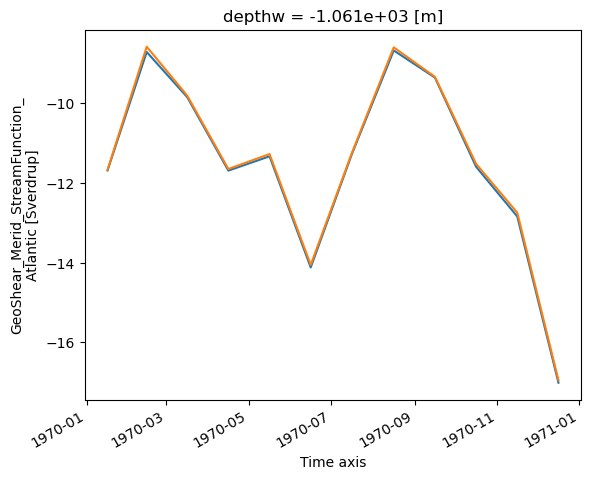

In [ ]:
geo_moc = load_dataset_from_grid_type('moc', (1970, 1971), nest, 'VIKING20X.L46-KFS003', '1m', chunks={'y': 100, 'time_counter': 1}, folder = 'derived')

geo_moc.zomsfatl_sh.isel(y = target_y, depthw = 24).plot(label = 'CDFTools')
plt.plot(geo_moc.time_counter,amoc[:, target_y, 24], label = 'Numpy')

# plt.legend()


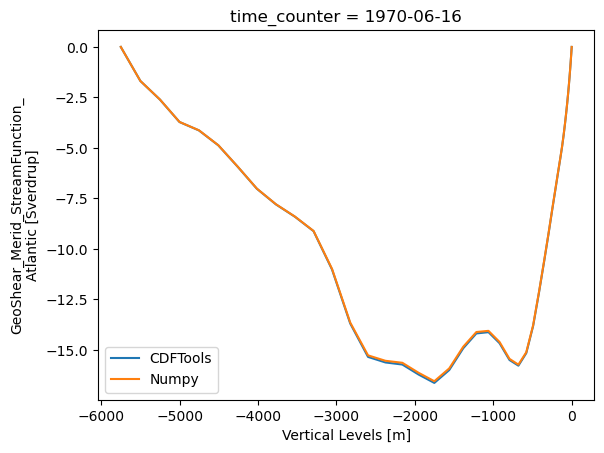

In [9]:

geo_moc.zomsfatl_sh.isel(y = target_y, time_counter = 5).plot(label = 'CDFTools')
plt.plot(geo_moc.depthw, amoc[5, target_y], label = 'Numpy')
plt.legend()

## Mooring Idea 

In [33]:
mooring_positions = [
    [26.52,-76.74],
    [26.50,-76.50],
    [26.99,-16.23],
    [24.52,-50.57],
    [24.52,-41.21]
]


longitudes = ds_m.nav_lon
latitudes = ds_m.nav_lat

from scipy.spatial import cKDTree

tree = cKDTree(np.stack([latitudes.values.ravel(), longitudes.values.ravel()], axis = 1))

distances, indices = tree.query(mooring_positions)

indices = np.unravel_index(indices, longitudes.values.shape)

mooring_indices_y = indices[0]
mooring_indices_x = indices[1]



In [42]:
vmask = ds_m.vmask.transpose('x', 'y', 'z').values
e3v = ds_m.e3v_0.transpose('x', 'y', 'z').values * vmask

In [21]:
mooring_i = 1
mooring_j = 2



mean_y_index = (mooring_indices_y[mooring_i] + mooring_indices_y[mooring_j]) // 2

distance = ds_m.e1u.isel(y = mean_y_index, x = slice(mooring_indices_x[mooring_i], mooring_indices_x[mooring_j])).sum('x').values


non_blocked_depth = (1 - ds_m.tmask).isel(y = mean_y_index, x = slice(mooring_indices_x[mooring_i], mooring_indices_x[mooring_j])).sum('x').values

last_empty_cell_index  = np.max(np.argwhere(non_blocked_depth == 0))



distance, last_empty_cell_index





    

(array(5984552.44340312), 30)

In [27]:
temp = ds_T.isel(x = mooring_indices_x, y = mooring_indices_y).votemper
sal = ds_T.isel(x = mooring_indices_x, y = mooring_indices_y).vosaline

In [34]:
from gsw import SA_from_SP, CT_from_pt, rho


ct = CT_from_pt(sal, temp)
rho = gsw.rho(sal, ct, temp.z).rename("dens")
rho

<xarray.DataArray 'dens' (time_counter: 12, z: 46, y: 5, x: 5)>
dask.array<rho, shape=(12, 46, 5, 5), dtype=float64, chunksize=(1, 46, 5, 2), chunktype=numpy.ndarray>
Coordinates:
    nav_lat        (y, x) float32 dask.array<chunksize=(5, 2), meta=np.ndarray>
    nav_lon        (y, x) float32 dask.array<chunksize=(5, 2), meta=np.ndarray>
  * z              (z) float32 3.047 9.454 16.36 ... 5.625e+03 5.875e+03
    time_centered  (time_counter) datetime64[ns] dask.array<chunksize=(1,), meta=np.ndarray>
  * time_counter   (time_counter) datetime64[ns] 1970-01-16T12:00:00 ... 1970...
  * x              (x) int64 434 439 1644 958 1145
  * y              (y) int64 1275 1274 1285 1230 1230
Attributes:
    standard_name:       sea_water_practical_salinity
    long_name:           salinity
    units:               1e-3
    online_operation:    average
    interval_operation:  300 s
    interval_write:      1 d
    cell_methods:        time: mean (interval: 300 s) time_counter: mean

In [37]:
mooring_i_density = rho.isel(x = mooring_i, y = mooring_i).values
mooring_j_density = rho.isel(x = mooring_j, y = mooring_j).values

In [38]:
diff = mooring_i_density - mooring_j_density

In [40]:
rpi = np.arccos(-1)

zcoef = 2*2*rpi/( 24.0 * 3600. )* np.sin ( rpi * ((mooring_positions[mooring_i][0] + mooring_positions[mooring_j][0]) / 2) /180.0)

zcoef = -9.81 / 1025.0 / zcoef

zcoef

-146.22334372845737

In [71]:
mooring_e3 = ((e3v[mooring_indices_x[mooring_i], mooring_indices_y[mooring_i]] + e3v[mooring_indices_x[mooring_j], mooring_indices_y[mooring_j]]) / 2).reshape(1, -1)
mooring_e3[last_empty_cell_index+1:] = 0

In [72]:
vgeo = diff / distance * zcoef * mooring_e3

In [66]:
diff.shape

(12, 46)

In [73]:
cumulated_vgeo = vgeo[:, :last_empty_cell_index+1][:, ::-1].cumsum(axis = -1)[:, ::-1]

dvgeo = np.zeros_like(vgeo)
dvgeo[:, :last_empty_cell_index+1] = cumulated_vgeo

In [74]:
zv = np.zeros_like(dvgeo)
for zk in range(dvgeo.shape[1] -1, -1, -1):
    if zk == dvgeo.shape[1] -1:
        zv[:,zk] = .5 * dvgeo[:,zk]
    else:
        zv[:,zk] = .5 * (dvgeo[:,zk] + dvgeo[:,zk + 1])

In [75]:
zv

array([[ 1.18164897e-02,  1.17025968e-02,  1.15797908e-02,
         1.14458740e-02,  1.12981461e-02,  1.11332611e-02,
         1.09470827e-02,  1.07344158e-02,  1.04906398e-02,
         1.02244278e-02,  9.91539628e-03,  9.53883074e-03,
         9.09818161e-03,  8.57184583e-03,  7.92741285e-03,
         7.13705660e-03,  6.17809262e-03,  5.06356080e-03,
         3.86649107e-03,  2.69130440e-03,  1.61373492e-03,
         6.87381140e-04,  3.07112114e-05, -1.98186169e-04,
        -7.35545943e-05,  1.43158101e-04,  2.64151122e-04,
         2.70891308e-04,  2.31513724e-04,  1.57347552e-04,
         5.52141674e-05,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 1.13042055e-02,  1.11766190e-02,  1.10391650e-02,
         1.08893651e-02,  1.07

In [76]:
dvbt = np.nansum(mooring_e3 * zv, axis = -1)
hdep = np.nansum(mooring_e3, axis = -1)
dmoc_sh = distance * mooring_e3 * zv
dvbt = dvbt/ hdep
dmoc_btw = - dvbt.reshape(-1, 1) * distance * mooring_e3

dmoc_sh.shape
dmoc_btw.shape

In [89]:
dmoc_sh = dmoc_sh - dmoc_btw
dmoc_sh = np.nancumsum(dmoc_sh[:, ::-1], axis = 1)[:, ::-1] / 1e6
dmoc_sh[:, 24]

In [95]:
mooring_pairs = [(0,1), (1,3), (3,4), (4,2)]

temp = ds_T.isel(x = mooring_indices_x, y = mooring_indices_y).votemper
sal = ds_T.isel(x = mooring_indices_x, y = mooring_indices_y).vosaline

from gsw import SA_from_SP, CT_from_pt, rho
ct = CT_from_pt(sal, temp)
rho = gsw.rho(sal, ct, temp.z).rename("dens").compute()

npt = ds_T.time_counter.shape[0]
npk = ds_T.z.shape[0]


transport = np.empty(shape = (npt, npk, len(mooring_pairs)))


for section_i, (mooring_i, mooring_j) in enumerate(mooring_pairs):
    mean_y_index = (mooring_indices_y[mooring_i] + mooring_indices_y[mooring_j]) // 2

    distance = ds_m.e1u.isel(y = mean_y_index, x = slice(mooring_indices_x[mooring_i], mooring_indices_x[mooring_j])).sum('x').values


    non_blocked_depth = (1 - ds_m.tmask).isel(y = mean_y_index, x = slice(mooring_indices_x[mooring_i], mooring_indices_x[mooring_j])).sum('x').values

    last_empty_cell_index  = np.max(np.argwhere(non_blocked_depth == 0))

    mooring_i_density = rho.isel(x = mooring_i, y = mooring_i).values
    mooring_j_density = rho.isel(x = mooring_j, y = mooring_j).values

    diff = mooring_i_density - mooring_j_density

    rpi = np.arccos(-1)

    zcoef = 2*2*rpi/( 24.0 * 3600. )* np.sin ( rpi * ((mooring_positions[mooring_i][0] + mooring_positions[mooring_j][0]) / 2) /180.0)

    zcoef = -9.81 / 1025.0 / zcoef

    mooring_e3 = ((e3v[mooring_indices_x[mooring_i], mooring_indices_y[mooring_i]] + e3v[mooring_indices_x[mooring_j], mooring_indices_y[mooring_j]]) / 2).reshape(1, -1)
    mooring_e3[last_empty_cell_index+1:] = 0

    vgeo = diff / distance * zcoef * mooring_e3

    cumulated_vgeo = vgeo[:, :last_empty_cell_index+1][:, ::-1].cumsum(axis = -1)[:, ::-1]

    dvgeo = np.zeros_like(vgeo)
    dvgeo[:, :last_empty_cell_index+1] = cumulated_vgeo

    zv = np.zeros_like(dvgeo)
    for zk in range(dvgeo.shape[1] -1, -1, -1):
        if zk == dvgeo.shape[1] -1:
            zv[:,zk] = .5 * dvgeo[:,zk]
        else:
            zv[:,zk] = .5 * (dvgeo[:,zk] + dvgeo[:,zk + 1])

    dvbt = np.nansum(mooring_e3 * zv, axis = -1)
    hdep = np.nansum(mooring_e3, axis = -1)
    dmoc_sh = distance * mooring_e3 * zv
    dvbt = dvbt/ hdep
    dmoc_btw = - dvbt.reshape(-1, 1) * distance * mooring_e3


    dmoc_sh = dmoc_sh - dmoc_btw
    dmoc_sh = np.nancumsum(dmoc_sh[:, ::-1], axis = 1)[:, ::-1] / 1e6

    transport[:, :, section_i] = dmoc_sh
    

In [96]:
transport[:, 24]

array([[ 8.09433265,  4.72207615, 12.89734418,  4.71364058],
       [ 9.22807655,  5.46449914,  2.00103374,  4.71700235],
       [ 3.12365835,  6.11242246, -1.66469307,  4.92111153],
       [ 4.15642965,  6.42796661, -1.00952302,  5.63568753],
       [ 0.9739055 ,  7.4714905 ,  0.73743842,  6.7081038 ],
       [ 5.21440093,  7.14462668, -2.64499023,  6.41401368],
       [10.45365024,  3.11859639, -0.7820044 ,  3.0608666 ],
       [13.68851304,  3.87367466,  1.358767  ,  2.00549825],
       [ 4.14237164,  8.75635772, -3.22203249,  6.27527775],
       [ 3.70390578,  6.97899725, -4.63362224,  8.78987437],
       [ 8.48895491,  6.7258904 , -0.62056548, 10.60973034],
       [ 4.45846712,  7.98089139,  7.92555355,  8.63188235]])

## Mooring Contribution

In [6]:
rpi = np.arccos(-1)

zcoef = 2*2*rpi/( 24.0 * 3600. )* np.sin ( rpi * gphiv /180.0)
zcoef = np.where(np.abs(gphiv) > 5, zcoef, np.nan)

zcoef = np.where(zcoef != 0, -9.81 / 1025.0 / zcoef, 0.0)

In [65]:
amoc = np.empty(shape = (dens_all_t.shape[0], dens_all_t.shape[2], dens_all_t.shape[3]))
dmoc_alongx_allt = np.empty_like(dens_all_t)
for ti, dens in enumerate(dens_all_t): 

    diff = np.diff(dens, axis = 0)

    # multiply elementwise with the u mask and divide by the width of the u box
    diff = (np.nan_to_num(diff) * umask[:-1, :, :]) / e1u[:-1, :, np.newaxis]

    drho = np.zeros_like(dens)
    drho[1:-1, :-1] = diff[:-1, :-1] + diff[1:, :-1] + diff[:-1, 1:] + diff[1:, 1:] 


    zmsv = np.ones_like(dens)
    zmsv[1:, :-1] =umask[1:, :-1] + umask[:-1, :-1] + umask[1:, 1:] + umask[:-1, 1:]
    zmsv = np.where(zmsv > 0, 1 / zmsv, 1)




    dvgeo = drho * zcoef[:,:,np.newaxis] * zmsv * e3v * tmaskatl[:, :, np.newaxis]

    dvgeo = np.where(vmask == 1, dvgeo, np.nan)
    dvgeo = np.nancumsum(dvgeo[..., ::-1], axis = -1)[..., ::-1]

    # move to v level 
    zv = np.zeros_like(dvgeo)
    for zk in range(dvgeo.shape[2] -1, -1, -1):
        if zk == dvgeo.shape[2] -1:
            zv[:,:,zk] = .5 * dvgeo[:,:,zk]
        else:
            zv[:,:,zk] = .5 * (dvgeo[:,:,zk] + dvgeo[:,:,zk + 1])


    zv = np.where(vmask == 1, zv, np.nan)

    dvbt = np.nansum(e3v * zv, axis = -1)
    hdep = np.nansum(e3v, axis = -1)


    dvbt = np.where(hdep == 0, 0, dvbt / hdep)
    dvbt = np.where(tmaskatl == 1, dvbt, np.nan)

    dmoc_sh = -e1v[:, :, np.newaxis] * e3v * zv * tmaskatl[:, :, np.newaxis]
    dmoc_btw = -dvbt[:, :, np.newaxis] * e1v[:, :, np.newaxis] * e3v


    dmoc_sh_x = dmoc_sh - dmoc_btw
    dmoc_sh = dmoc_sh - dmoc_btw

    dmoc_sh = np.nansum(dmoc_sh, axis = 0)
    dmoc_sh = np.nancumsum(dmoc_sh[:, ::-1], axis = 1)[:, ::-1] / 1e6

    amoc[ti] = dmoc_sh
    dmoc_alongx_allt[ti] = dmoc_sh_x

/scratch/SlurmTMP/smomw507.11112384/ipykernel_4091177/1345325902.py:16: RuntimeWarning: divide by zero encountered in divide
  zmsv = np.where(zmsv > 0, 1 / zmsv, 1)
/scratch/SlurmTMP/smomw507.11112384/ipykernel_4091177/1345325902.py:41: RuntimeWarning: invalid value encountered in divide
  dvbt = np.where(hdep == 0, 0, dvbt / hdep)


In [14]:
amoc[0, 1273, 24]

-11.67308693082609

In [27]:
dmoc_sh_x.shape

(2404, 2499, 46)

In [130]:
dmoc_sh_x_cum = np.nancumsum(dmoc_alongx_allt[0, ..., ::-1], axis = -1)[..., ::-1] / 1e6

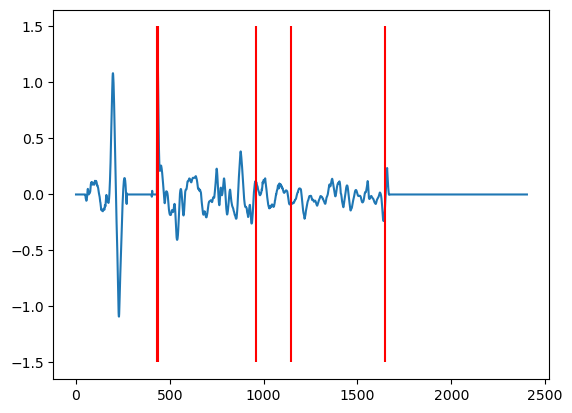

In [131]:
plt.plot(dmoc_sh_x_cum[:, 1273, 24])

plt.vlines(mooring_indices_x, ymin = -1.5, ymax = 1.5, color = 'r')

In [31]:

np.nansum(dmoc_sh_x_cum[:, 1273, 24], axis = 0)

-11.673086930826093

In [34]:
mooring_indices_x

array([ 434,  439, 1644,  958, 1145])

In [156]:
mooring_pairs = [(0,1), (1,3), (3,4), (4,2)]

npk = dmoc_alongx_allt.shape[-1]
npt = dmoc_alongx_allt.shape[0]
npiglo = dmoc_alongx_allt.shape[1]

transport = np.zeros(shape = (npt,len(mooring_pairs), npk))
explained_mooring_transport_per_x = np.zeros(shape = (npt,len(mooring_pairs), npiglo, npk))

for section_i, (mooring_i, mooring_j) in enumerate(mooring_pairs):
    mean_y_index = (mooring_indices_y[mooring_i] + mooring_indices_y[mooring_j]) // 2

    distance = ds_m.e1u.isel(y = mean_y_index, x = slice(mooring_indices_x[mooring_i], mooring_indices_x[mooring_j])).sum('x').values


    non_blocked_depth = (1 - ds_m.tmask).isel(y = 1270, x = slice(mooring_indices_x[mooring_i]+1, mooring_indices_x[mooring_j])).sum('x').values

    last_empty_cell_index  = np.max(np.argwhere(non_blocked_depth <  .1 * (mooring_indices_x[mooring_j]-  mooring_indices_x[mooring_i])))
    print(last_empty_cell_index)
    # last_empty_cell_index = npk-1

    dmoc_sh_within_moorings = dmoc_alongx_allt[:, mooring_indices_x[mooring_i]:mooring_indices_x[mooring_j]]
    print('dmoc_sh_within_moorings shape', dmoc_sh_within_moorings.shape)

    cumsum = np.nancumsum(dmoc_sh_within_moorings[..., :last_empty_cell_index+1][..., ::-1], axis = -1)[..., ::-1] / 1e6
    print('cumsum shape', cumsum.shape)

    explained_mooring_transport_per_x[:, section_i, mooring_indices_x[mooring_i]:mooring_indices_x[mooring_j], :last_empty_cell_index+1] = cumsum[...,mean_y_index,:]
    transport[:, section_i, :last_empty_cell_index+1] = np.nansum(cumsum[...,mean_y_index,:], axis = 1)



40
dmoc_sh_within_moorings shape (12, 5, 2499, 46)
cumsum shape (12, 5, 2499, 41)
41
dmoc_sh_within_moorings shape (12, 519, 2499, 46)
cumsum shape (12, 519, 2499, 42)
34
dmoc_sh_within_moorings shape (12, 187, 2499, 46)
cumsum shape (12, 187, 2499, 35)
36
dmoc_sh_within_moorings shape (12, 499, 2499, 46)
cumsum shape (12, 499, 2499, 37)


Text(0, 0.5, 'Transport [Sv]')

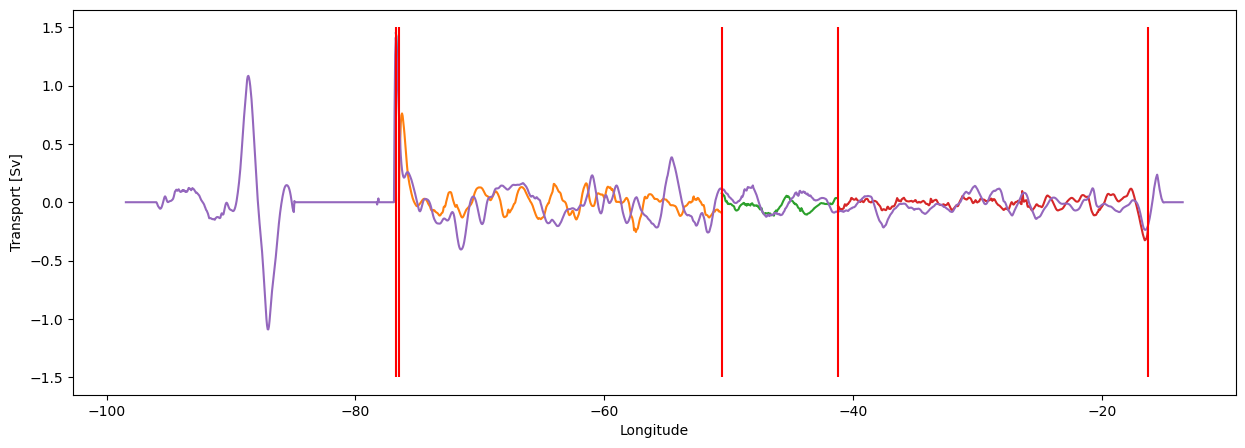

In [181]:
fig = plt.figure(figsize = (15, 5))
ax = fig.add_subplot(111)

moc = 0
for section_i, (mooring_i, mooring_j) in enumerate(mooring_pairs):
    ax.plot(ds_m.nav_lon.isel(y = 1270, x = slice(mooring_indices_x[mooring_i],mooring_indices_x[mooring_j] )).values, explained_mooring_transport_per_x[0, section_i,mooring_indices_x[mooring_i]:mooring_indices_x[mooring_j] , 24], label = f'{mooring_i} - {mooring_j}')
    # ax.plot(ds_m.nav_lon.isel(y = 1270, x = slice(mooring_indices_x[mooring_i],mooring_indices_x[mooring_j] )).values, np.cumsum(explained_mooring_transport_per_x[0, section_i,mooring_indices_x[mooring_i]:mooring_indices_x[mooring_j] , 24]) + moc, label = f'{mooring_i} - {mooring_j}')

    moc = (np.cumsum(explained_mooring_transport_per_x[0, section_i,mooring_indices_x[mooring_i]:mooring_indices_x[mooring_j] , 24]) + moc)[-1]

ax.plot(ds_m.nav_lon.isel(y = 1270, x = slice(0,1700 )).values,dmoc_sh_x_cum[0:1700, 1273, 24])
# ax.plot(ds_m.nav_lon.isel(y = 1270, x = slice(0,1700 )).values,np.cumsum(dmoc_sh_x_cum[0:1700, 1273, 24]))

ax.vlines(ds_m.nav_lon.isel(y = 1270).values[mooring_indices_x], ymin = -1.5, ymax = 1.5, color = 'r')


ax.set_xlabel('Longitude')
ax.set_ylabel('Transport [Sv]')

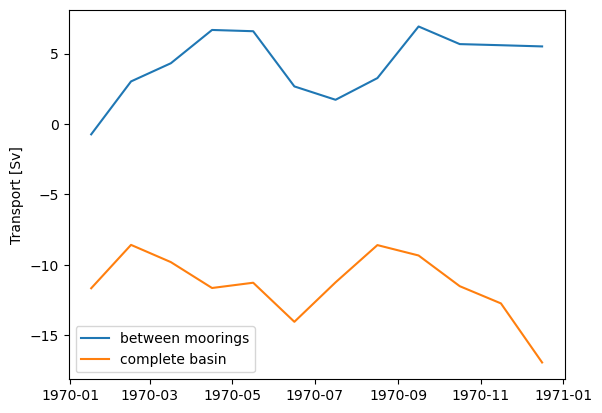

In [158]:


plt.plot(rho.time_counter.values,np.sum(transport, axis = 1)[:,  24], label = 'between moorings')
plt.plot(rho.time_counter.values,amoc[:, 1273,24], label = 'complete basin')

plt.ylabel('Transport [Sv]')
plt.legend()

In [127]:
dmoc_alongx_allt

array([[[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        ...,

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan

In [128]:

mooring_indices_y

array([1275, 1274, 1285, 1230, 1230])

In [85]:
(1274+1285)//2

1279

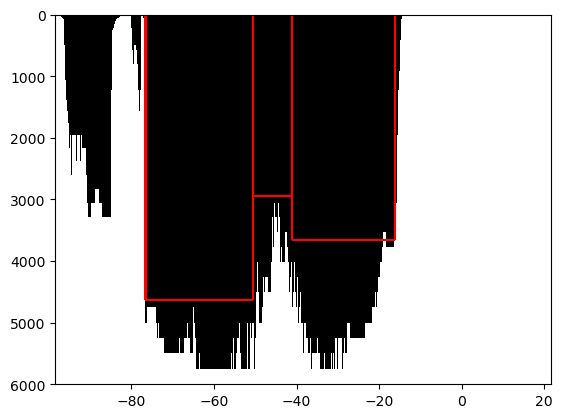

In [168]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.pcolormesh(ds_m.nav_lon.isel(y = 1270).values, ds_m.nav_lev.values, 1 - ds_m.tmask.isel(y = 1270).values, cmap = 'gray')

for section_i, (mooring_i, mooring_j) in enumerate(mooring_pairs):
    non_blocked_depth = (1 - ds_m.tmask).isel(y = 1270, x = slice(mooring_indices_x[mooring_i]+1, mooring_indices_x[mooring_j])).sum('x').values

    last_empty_cell_index  = np.max(np.argwhere(non_blocked_depth <  .05 * (mooring_indices_x[mooring_j]-  mooring_indices_x[mooring_i])))

    # ax.vlines(mooring_indices_x[mooring_i], ymin = 0, ymax = 50, color = 'r')
    ax.vlines(ds_m.nav_lon.isel(y = 1270, x = mooring_indices_x[mooring_i]).values, ymin = 0, ymax = ds_m.nav_lev.isel(z = last_empty_cell_index).values, color = 'r')
    ax.vlines(ds_m.nav_lon.isel(y = 1270, x = mooring_indices_x[mooring_j]).values, ymin = 0, ymax = ds_m.nav_lev.isel(z = last_empty_cell_index).values, color = 'r')


    ax.hlines( ds_m.nav_lev.isel(z = last_empty_cell_index).values, xmin = ds_m.nav_lon.isel(y = 1270, x = mooring_indices_x[mooring_i]).values, xmax = ds_m.nav_lon.isel(y = 1270, x = mooring_indices_x[mooring_j]).values, color = 'r')

ax.invert_yaxis()

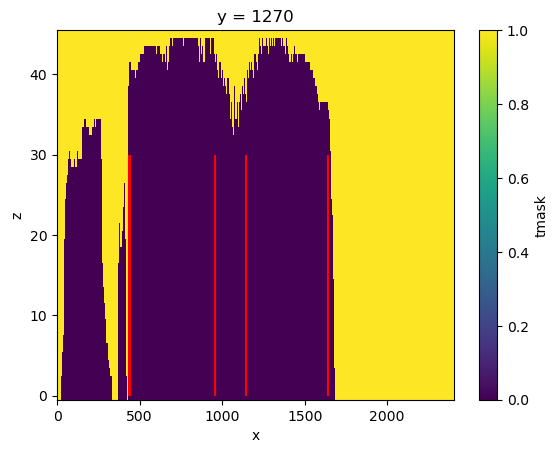

In [129]:

plt.vlines(mooring_indices_x, ymin = 0, ymax = 30, color = 'r')
(1- ds_m.tmask).isel(y = 1270).plot()

In [88]:
mooring_indices_x

array([ 434,  439, 1644,  958, 1145])

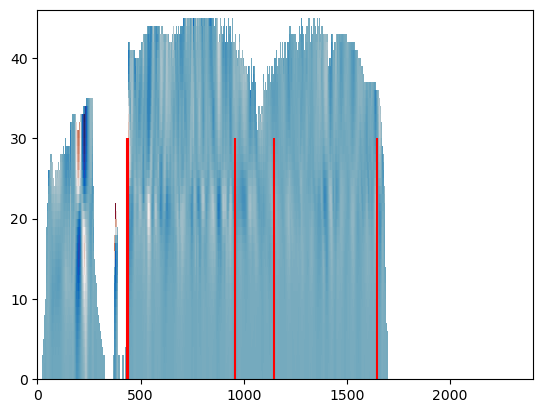

In [103]:
import cmocean
plt.pcolormesh(dmoc_alongx_allt[0, :, 1279].T, cmap = 'cmo.balance')
plt.vlines(mooring_indices_x, ymin = 0, ymax = 30, color = 'r')

TypeError: '<' not supported between instances of 'list' and 'int'

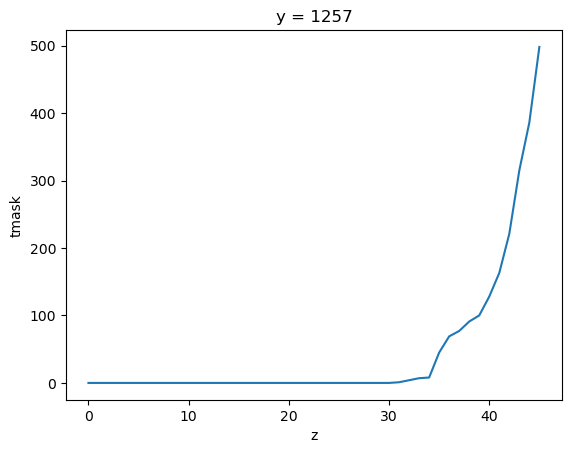

In [114]:
non_blocked_depth = (1 - ds_m.tmask).isel(y = mean_y_index, x = slice(mooring_indices_x[mooring_i]+1, mooring_indices_x[mooring_j])).sum('x').plot()

last_empty_cell_index  = np.max(np.argwhere(non_blocked_depth  < 50))
last_empty_cell_index

In [118]:
mooring_indices_y

array([1275, 1274, 1285, 1230, 1230])